# TEKNOLAB 2025-2026: Amerikan İşaret Dili (ASL) Tanıma Sistemi
**Ekip:** TEKNOLAB 
**Proje Amacı:** Kameradan alınan gerçek zamanlı görüntülerdeki Amerikan İşaret Dili (ASL) harflerini tespit edip sınıflandıran, yüksek doğruluk (%85+) ve düşük gecikme ($\le2$ sn) hedefleyen uçtan uca bir yapay zeka sistemi geliştirmek.

Bu notebook, veri ön işleme, YOLO11n mimarisi kullanılarak yapılan Fine-Tuning işlemi ve modelin performans metriklerinin analizini içermektedir.

In [1]:
# Gerekli Kütüphanelerin Kurulumu ve Drive Bağlantısı
!pip install roboflow ultralytics -q

from google.colab import drive
import os

try:
    drive.mount('/content/drive', force_remount=True)
    print("✅ Drive bağlandı! Model ağırlıkları güvene alındı.")
except:
    print("✅ Drive zaten bağlı, devam ediliyor.")

drive_yedek_yolu = "/content/drive/MyDrive/TeknoLAB_ASL/Yedekler"
os.makedirs(drive_yedek_yolu, exist_ok=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 112.2 MB/s eta 0:00:00
Mounted at /content/drive
✅ Drive bağlandı! Model ağırlıkları güvene alındı.


## 1. Veri Seti Analizi ve Veri Artırma (Augmentation)
Projemizde kullanılacak veri setini Roboflow üzerinden entegre ettik. Modelin aydınlatma değişikliklerine, açı farklılıklarına ve arka plan karmaşasına karşı direncini artırmak için eğitim aşamasında veri artırma (augmentation) uygulanmıştır. Veri seti `train`, `valid` ve `test` olarak 3'e bölünmüştür.

In [2]:
from roboflow import Roboflow

os.chdir("/content")

# Roboflow API ve Proje Bağlantısı
rf = Roboflow(api_key="YOUR_API_KEY")
project = rf.workspace("bill-ag8b9").project("american-sign-language-letters-gxpdm-k49nh")
version = project.version(3)

dataset = version.download("yolov8")
print(f"✅ Veri seti başarıyla yüklendi: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to American-sign-language-letters-3 in yolov8:: 100%|██████████| 7833/7833 [00:01<00:00, 3920.64it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Veri seti başarıyla yüklendi: /content/American-sign-language-letters-3


## 2. Model Mimarisi: YOLO11n Fine-Tuning
Gerçek zamanlı çıkarım (real-time inference) yapabilmek ve sistem kaynaklarını optimize etmek adına uç cihazlarda (edge devices) çalışmaya en uygun olan **YOLO11n** mimarisi tercih edilmiştir.
Önceden eğitilmiş (Pre-trained) ağırlıklar üzerine kendi ASL veri setimiz ile **50 Epoch** boyunca Fine-Tuning uygulanmıştır.

In [3]:
from ultralytics import YOLO

# Sıfır yolo modeli yükleme
model = YOLO("yolo11n.pt")

yaml_yolu = f"{dataset.location}/data.yaml"
print(f"🚀 Eğitim başlıyor! Hedef yaml: {yaml_yolu}")

# Eğitim (Eğer Colab oturumunda canlı eğitim yapılmayacaksa bu bloğu yorum satırına alıp jüriye açıklayabilirsiniz)
results = model.train(
    data=yaml_yolu,
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    project="/content/runs",
    name="asl_yolo11_augmented",
    save=True
)
print("✅ Eğitim tamamlandı! En iyi ağırlıklar (best.pt) kaydedildi.")

🚀 Eğitim başlıyor! Hedef yaml: /content/American-sign-language-letters-3/data.yaml
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/American-sign-language-letters-3/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=

## 3. Performans Metrikleri ve Model Başarısı
Modelimizin eğitim süreci bittikten sonra Validation (Doğrulama) veri seti üzerindeki kayıp (loss), doğruluk (precision/recall) ve Karmaşıklık Matrisi (Confusion Matrix) grafiklerini analiz ediyoruz.

📊 EĞİTİM METRİKLERİ (Loss, Precision, Recall, mAP)


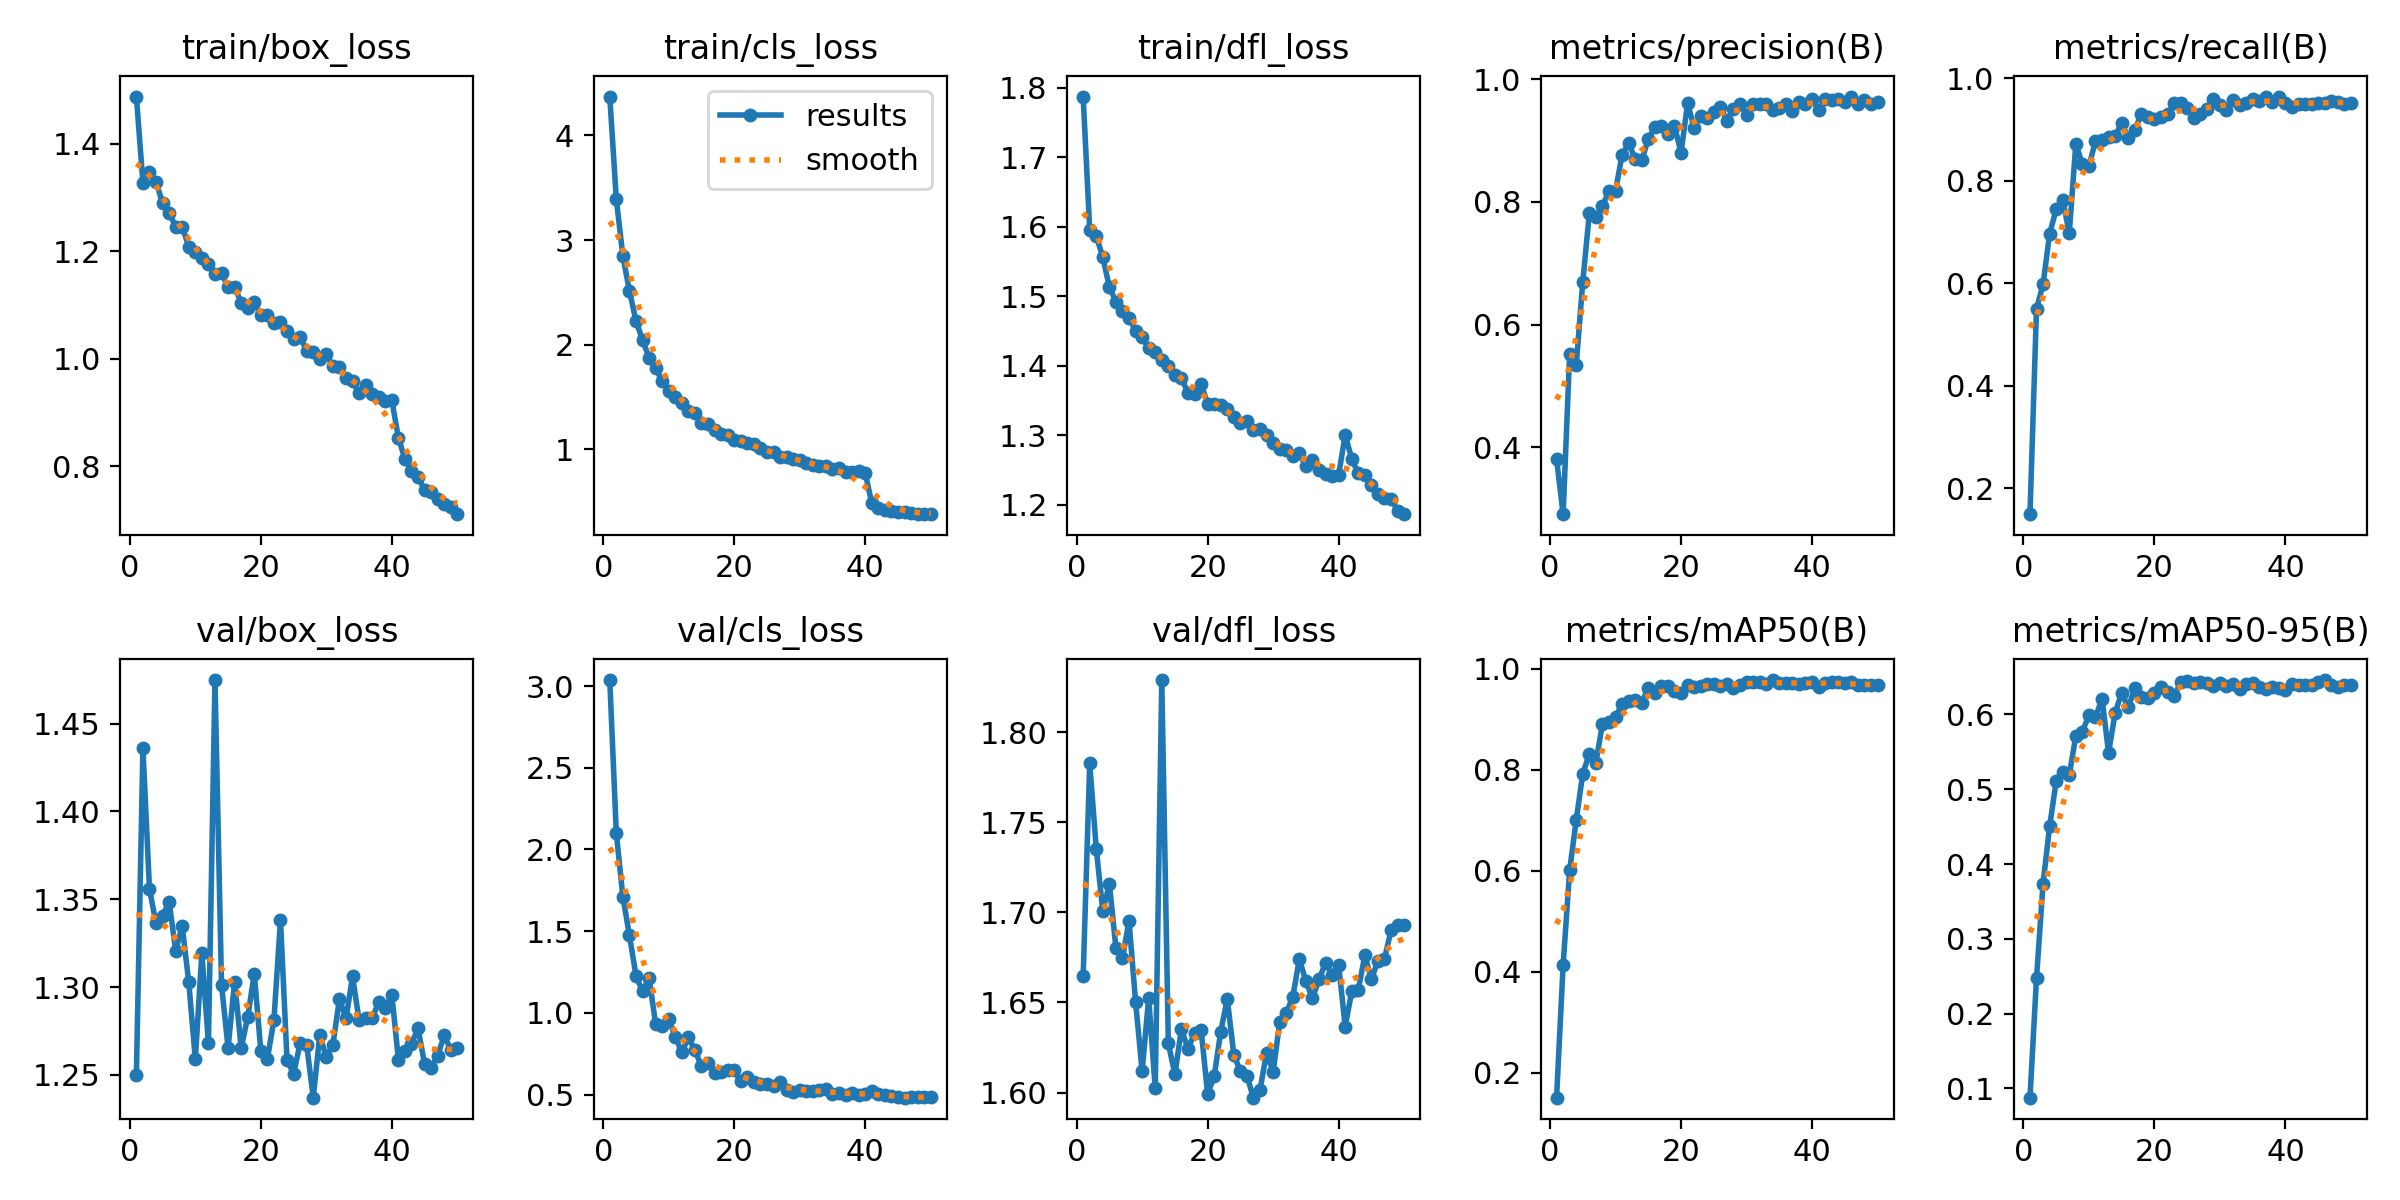


📈 CONFUSION MATRIX (Sınıflandırma Başarısı)


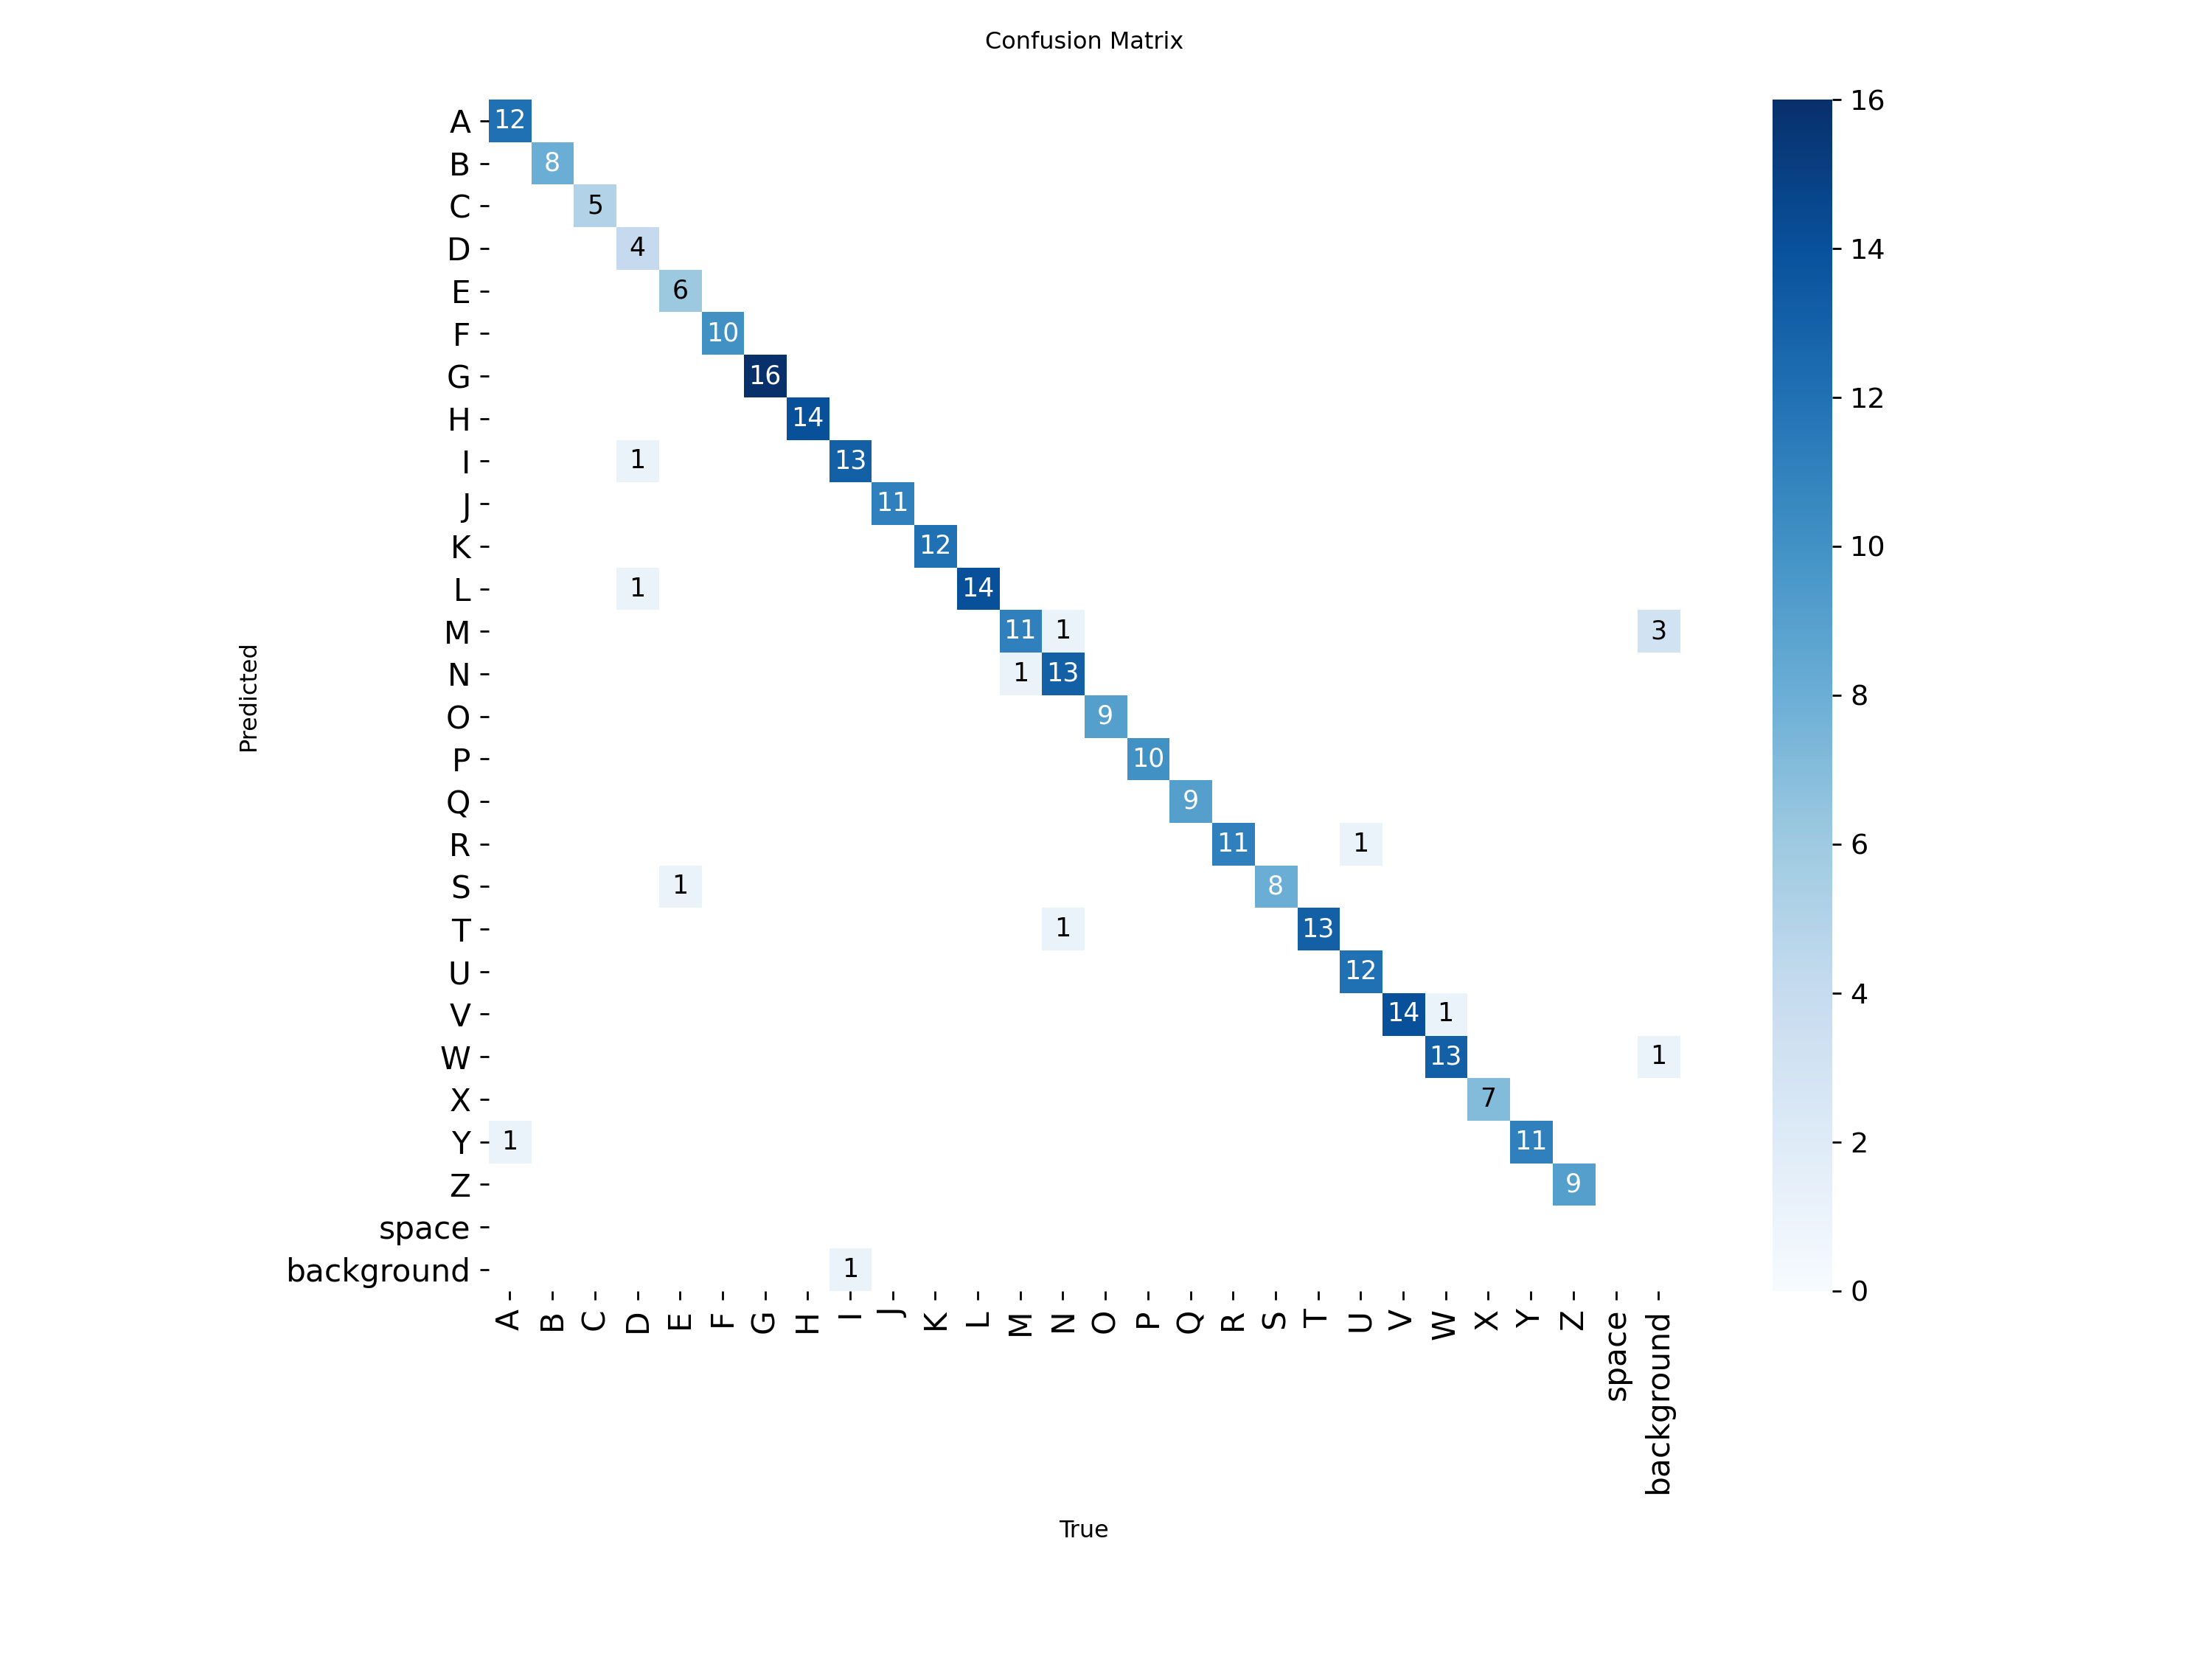

In [4]:
from IPython.display import Image, display

# Eğitim sonrası otomatik oluşan grafiklerin yolları
runs_dir = "/content/runs/asl_yolo11_augmented"
results_png = f"{runs_dir}/results.png"
confusion_matrix_png = f"{runs_dir}/confusion_matrix.png"

print("📊 EĞİTİM METRİKLERİ (Loss, Precision, Recall, mAP)")
if os.path.exists(results_png):
    display(Image(filename=results_png, width=1000))
else:
    print("Sonuç grafiği bulunamadı. Lütfen eğitim bloğunun çalıştığından emin olun.")

print("\n📈 CONFUSION MATRIX (Sınıflandırma Başarısı)")
if os.path.exists(confusion_matrix_png):
    display(Image(filename=confusion_matrix_png, width=800))

## 4. Model Dışa Aktarımı (Deployment Hazırlığı)
Eğitilen modelin Streamlit arayüzünde canlı (Kör Test) olarak çalıştırılabilmesi için elde edilen en iyi ağırlıkları (`best.pt`) ve eğitim metriklerini dışa aktarıyoruz.

In [5]:
import os
import shutil

# 1. YOLO'nun tüm çıktılarını (grafikler, best.pt, last.pt, metrikler, csv) kaydettiği kök klasör
yolo_ciktilari_klasoru = "/content/runs"
drive_yedek_yolu = "/content/drive/MyDrive/TeknoLAB_ASL/Yedekler"
zip_adi = "/content/ASL_Tum_Yolo_Ciktilari"

# Yedek klasörünün Drive'da var olduğundan emin olalım
os.makedirs(drive_yedek_yolu, exist_ok=True)

if os.path.exists(yolo_ciktilari_klasoru):
    print("📦 YOLO'nun ürettiği her şey (Ağırlıklar, Metrikler, Grafikler) eksiksiz zipleniyor...")
    shutil.make_archive(zip_adi, 'zip', yolo_ciktilari_klasoru)

    # 2. Ziplenen dosyayı DOĞRUDAN DRIVE'A kopyala
    hedef_zip_drive = os.path.join(drive_yedek_yolu, "ASL_Tum_Yolo_Ciktilari.zip")
    print("🚀 Drive'a aktarılıyor...")
    shutil.copy(f"{zip_adi}.zip", hedef_zip_drive)

    print(f"✅ Tüm çıktıların şurada güvende olacak: {hedef_zip_drive}")
else:
    print("❌ Eğitim klasörü bulunamadı. Lütfen eğitim kodunun hata vermeden çalıştığına emin ol.")

📦 YOLO'nun ürettiği her şey (Ağırlıklar, Metrikler, Grafikler) eksiksiz zipleniyor...
🚀 Drive'a aktarılıyor...
✅ Tüm çıktıların şurada güvende olacak: /content/drive/MyDrive/TeknoLAB_ASL/Yedekler/ASL_Tum_Yolo_Ciktilari.zip
